# 11 · Nigerian Fraud corpus (419) — subtype & Core fit

**Source:** `v2/data/raw/419_nigerian.txt` — mbox-style concatenation of Nigerian / advance-fee scam emails.

**Goal:** assess homogeneity as `advance_fee_scam_email`, identify subtypes, and decide whether to treat this as a **separate fraud-email family** for Core.

**Body extraction:** first blank-line block treated as headers; remainder is **email body** (plain text). Very long bodies are truncated for the LLM call; `body_char_len` and `body_truncated` are stored on the record.

**Outputs:**
- `v2/data/interim/annotated/nigerian_419_annotated.jsonl`

**Post-batch checks:** `scam_subtype` distribution, `core_candidate=yes` rate, and key boolean flags.

In [1]:
# ── 0. Setup ───────────────────────────────────────────────────────────────
import importlib.util
import json
import os
import re
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI, APIError, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from tqdm.auto import tqdm


def _find_v2_root() -> Path:
    c = Path(globals().get("__vsc_ipynb_file__", globals().get("__file__", "."))).resolve()
    for p in [c, *c.parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists() and (p / "notebooks").exists():
            return p
    raise RuntimeError("Cannot find v2/ project root")


V2_ROOT = _find_v2_root()
RAW_TXT = V2_ROOT / "data" / "raw" / "419_nigerian.txt"
INTERIM = V2_ROOT / "data" / "interim" / "annotated"
OUT_TABLES = V2_ROOT / "outputs" / "tables"
INTERIM.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

spec = importlib.util.spec_from_file_location(
    "_ann_common", V2_ROOT / "notebooks" / "02_dataset_design" / "_ann_common.py"
)
ac = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ac)

load_dotenv(V2_ROOT / ".env" if (V2_ROOT / ".env").exists() else None)
api_key = os.environ.get("OPENROUTER_API_KEY", "")
if not api_key:
    raise EnvironmentError(f"Set OPENROUTER_API_KEY in {V2_ROOT / '.env'}")

ANNOTATION_MODEL = "openai/gpt-4o-mini"
client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=api_key)

MAX_BODY_CHARS = 16_000
BATCH_SIZE = 4
SLEEP_SEC = 2.5
MAX_NEW_THIS_RUN = 30
OUT_JSONL = INTERIM / "nigerian_419_annotated.jsonl"

print("V2_ROOT :", V2_ROOT)
print("RAW     :", RAW_TXT)
print("OUT     :", OUT_JSONL)

V2_ROOT : /Users/askar/projects/antifraud-deepfake-detection/v2
RAW     : /Users/askar/projects/antifraud-deepfake-detection/v2/data/raw/419_nigerian.txt
OUT     : /Users/askar/projects/antifraud-deepfake-detection/v2/data/interim/annotated/nigerian_419_annotated.jsonl


In [2]:
# ── 1. Parse mbox-style file → bodies ───────────────────────────────────────
assert RAW_TXT.exists(), f"Missing: {RAW_TXT}"

raw = RAW_TXT.read_text(encoding="utf-8", errors="replace")
# Split on lines starting with "From " (classic mbox separator)
indices = [m.start() for m in re.finditer(r"^From \S", raw, flags=re.MULTILINE)]
messages: list[str] = []
for i, start in enumerate(indices):
    end = indices[i + 1] if i + 1 < len(indices) else len(raw)
    messages.append(raw[start:end].strip())

def extract_body(msg: str) -> str:
    if "\n\n" not in msg:
        return msg
    return msg.split("\n\n", 1)[1].strip()

records: list[dict] = []
for mi, m in enumerate(messages):
    full_body = extract_body(m)
    trunc = len(full_body) > MAX_BODY_CHARS
    text_for_llm = full_body[:MAX_BODY_CHARS] if trunc else full_body
    records.append(
        {
            "text": text_for_llm,
            "source_file": "419_nigerian.txt",
            "message_index": mi,
            "body_char_len": len(full_body),
            "body_truncated": trunc,
        }
    )

print("Messages:", len(records))
lens = [r["body_char_len"] for r in records]
print("Body char len: min", min(lens), "median", sorted(lens)[len(lens) // 2], "max", max(lens))
print("Truncated for LLM (>", MAX_BODY_CHARS, "):", sum(r["body_truncated"] for r in records))

Messages: 3978
Body char len: min 96 median 2860 max 608258
Truncated for LLM (> 16000 ): 27


## Annotation schema (419 email body)

| Field | Values |
|-------|--------|
| `scam_subtype` | inheritance_or_estate_transfer, lottery_or_prize_claim, business_investment_opportunity, diplomatic_package_or_fund_release, oil_contract_or_large_transfer, romance_or_personalized_financial_scam, generic_advance_fee_scam, unclear_other |
| `core_candidate` | yes / maybe / no |
| Binary flags | `has_*` as yes/no |
| `confidence` | high / medium / low |

`scenario_family` in JSONL = `scam_subtype` (for `_ann_common` index).

In [3]:
SYSTEM_PROMPT = '''
You are annotating scam emails for a research dataset on LLM-generated text detection in anti-fraud systems.

Your task is NOT to summarize the email.
Your task is to assign structured labels describing the scam subtype.

Return output as strict JSON with the following keys:

{
  "scam_subtype": "...",
  "core_candidate": "...",
  "has_large_sum": "yes|no",
  "has_confidentiality_request": "yes|no",
  "has_upfront_fee_or_processing_cost": "yes|no",
  "has_reward_or_percentage_offer": "yes|no",
  "has_identity_or_background_story": "yes|no",
  "has_reply_or_contact_cta": "yes|no",
  "confidence": "high|medium|low"
}

Allowed values for "scam_subtype":
- inheritance_or_estate_transfer
- lottery_or_prize_claim
- business_investment_opportunity
- diplomatic_package_or_fund_release
- oil_contract_or_large_transfer
- romance_or_personalized_financial_scam
- generic_advance_fee_scam
- unclear_other

Definitions:
- inheritance_or_estate_transfer: inheritance, deceased client, estate transfer, next-of-kin narrative
- lottery_or_prize_claim: winnings, lottery, prize release, lucky draw, reward claim
- business_investment_opportunity: business proposal, investment opportunity, partnership, foreign transfer proposal
- diplomatic_package_or_fund_release: diplomatic courier, package release, central bank release, frozen fund or transfer release
- oil_contract_or_large_transfer: oil/mining/government contract money, large international transfer, commission
- romance_or_personalized_financial_scam: personalized emotional contact with financial angle
- generic_advance_fee_scam: clearly 419 / advance-fee style but no narrower subtype fits well
- unclear_other: too noisy, too ambiguous, or not clearly one of the above

Allowed values for "core_candidate":
- yes
- maybe
- no

Meaning:
- yes: clearly fits an advance-fee / scam fraud-email family suitable for Core expansion
- maybe: scam-like but less canonical or partially ambiguous
- no: not suitable as a Core fraud-email example

Annotation rules:
1. Choose the most specific subtype that fits.
2. Mark has_large_sum=yes when a large amount of money, prize, estate, contract amount, or transfer amount is central to the message.
3. Mark has_confidentiality_request=yes if secrecy, discretion, confidentiality, or private handling is explicitly requested.
4. Mark has_upfront_fee_or_processing_cost=yes if the email asks for payment, release fee, processing fee, transfer fee, courier fee, or related advance payment.
5. Mark has_reward_or_percentage_offer=yes if the sender promises a share, reward, commission, or percentage.
6. Mark has_identity_or_background_story=yes if the email includes a narrative identity or backstory explaining why the recipient is contacted.
7. Mark has_reply_or_contact_cta=yes if the email asks to reply, contact, respond, call, or continue the transaction.
8. Use confidence=low only when the email is strongly ambiguous or corrupted.
9. Output JSON only. No explanation.
'''

USER_TEMPLATE = '''Annotate the following email for scam subtype analysis.

Email text:
"""{email_text}"""
'''

In [4]:
# ── 3. Validation & API ────────────────────────────────────────────────────
YN = {"yes", "no"}
SUBTYPES = {
    "inheritance_or_estate_transfer",
    "lottery_or_prize_claim",
    "business_investment_opportunity",
    "diplomatic_package_or_fund_release",
    "oil_contract_or_large_transfer",
    "romance_or_personalized_financial_scam",
    "generic_advance_fee_scam",
    "unclear_other",
}
CORE = {"yes", "maybe", "no"}
CONF = {"high", "medium", "low"}


def validate_419_ann(d: dict) -> dict:
    st = d.get("scam_subtype", "unclear_other")
    if st not in SUBTYPES:
        st = "unclear_other"
    cc = d.get("core_candidate", "maybe")
    if cc not in CORE:
        cc = "maybe"

    def yn(x, default="no"):
        v = str(x).strip().lower()
        return v if v in YN else default

    conf = str(d.get("confidence", "low")).strip().lower()
    if conf not in CONF:
        conf = "low"
    return {
        "scam_subtype": st,
        "core_candidate": cc,
        "has_large_sum": yn(d.get("has_large_sum")),
        "has_confidentiality_request": yn(d.get("has_confidentiality_request")),
        "has_upfront_fee_or_processing_cost": yn(d.get("has_upfront_fee_or_processing_cost")),
        "has_reward_or_percentage_offer": yn(d.get("has_reward_or_percentage_offer")),
        "has_identity_or_background_story": yn(d.get("has_identity_or_background_story")),
        "has_reply_or_contact_cta": yn(d.get("has_reply_or_contact_cta")),
        "confidence": conf,
    }


def build_messages(email_text: str) -> list[dict]:
    return [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": USER_TEMPLATE.format(email_text=email_text)},
    ]


@retry(
    retry=retry_if_exception_type((RateLimitError, APIError)),
    wait=wait_exponential(multiplier=2, min=2, max=60),
    stop=stop_after_attempt(6),
)
def call_json(msgs: list[dict]) -> dict:
    raw = client.chat.completions.create(
        model=ANNOTATION_MODEL,
        messages=msgs,
        response_format={"type": "json_object"},
        temperature=0,
        max_tokens=320,
    ).choices[0].message.content
    return json.loads(raw)

In [8]:
# ── 4. Annotate (cached by text md5 of LLM payload) ─────────────────────────
idx = ac.load_flat_annotation_index(OUT_JSONL)
pending = [r for r in records if ac.md5_text_key(r["text"]) not in idx]
print("Already annotated:", len(idx), "| Pending:", len(pending))

batch_i = 0
for r in tqdm(pending[:MAX_NEW_THIS_RUN], desc="nigerian_419"):
    try:
        ann = validate_419_ann(call_json(build_messages(r["text"])))
    except Exception as e:
        ann = validate_419_ann({})
        ann["_parse_error"] = str(e)[:240]
    ts = datetime.now(timezone.utc).isoformat()
    extra = {
        "core_candidate": ann["core_candidate"],
        "has_large_sum": ann["has_large_sum"],
        "has_confidentiality_request": ann["has_confidentiality_request"],
        "has_upfront_fee_or_processing_cost": ann["has_upfront_fee_or_processing_cost"],
        "has_reward_or_percentage_offer": ann["has_reward_or_percentage_offer"],
        "has_identity_or_background_story": ann["has_identity_or_background_story"],
        "has_reply_or_contact_cta": ann["has_reply_or_contact_cta"],
        "body_char_len": r.get("body_char_len"),
        "body_truncated": r.get("body_truncated"),
    }
    if "_parse_error" in ann:
        extra["_parse_error"] = ann["_parse_error"]
    flat = ac.make_flat_record(
        r,
        scenario_family=ann["scam_subtype"],
        annotation_confidence=ann["confidence"],
        annotation_model=ANNOTATION_MODEL,
        annotated_at=ts,
        extra=extra,
    )
    ac.append_jsonl(OUT_JSONL, flat)
    batch_i += 1
    if batch_i >= BATCH_SIZE:
        batch_i = 0
        time.sleep(SLEEP_SEC)

print("Total lines:", sum(1 for _ in OUT_JSONL.open() if _.strip()))

Already annotated: 25 | Pending: 3948


nigerian_419:   0%|          | 0/30 [00:00<?, ?it/s]

Total lines: 60


N: 60

--- scam_subtype (scenario_family) ---
scenario_family
inheritance_or_estate_transfer        23
diplomatic_package_or_fund_release    22
business_investment_opportunity        8
oil_contract_or_large_transfer         6
unclear_other                          1
Name: count, dtype: int64

core_candidate=yes: 98.3%
has_large_sum==yes: 100.0%
has_confidentiality_request==yes: 91.7%
has_upfront_fee_or_processing_cost==yes: 5.0%
has_reward_or_percentage_offer==yes: 91.7%
has_identity_or_background_story==yes: 98.3%
has_reply_or_contact_cta==yes: 98.3%


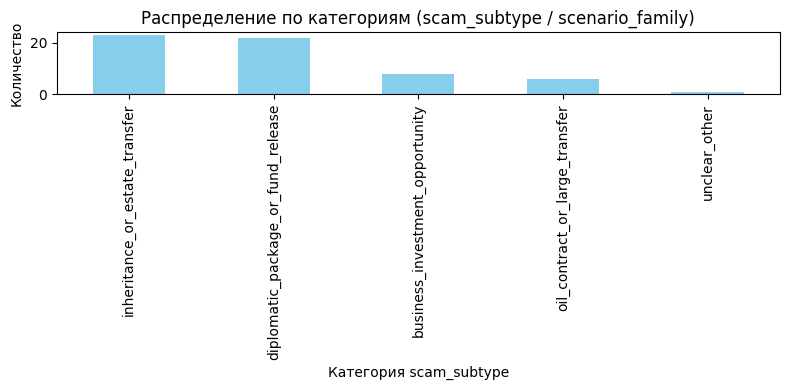


Wrote /Users/askar/projects/antifraud-deepfake-detection/v2/outputs/tables/nigerian_419_annotation_summary.csv


In [9]:
# ── 5. Post-annotation stats ─────────────────────────────────────────────────
import matplotlib.pyplot as plt

rows = ac.load_jsonl(OUT_JSONL)
if not rows:
    print("No annotations yet.")
else:
    pdf = pd.DataFrame(rows)
    print("N:", len(pdf))
    print("\n--- scam_subtype (scenario_family) ---")
    print(pdf["scenario_family"].value_counts())
    print(f"\ncore_candidate=yes: {(pdf['core_candidate']=='yes').mean():.1%}")
    for col in [
        "has_large_sum",
        "has_confidentiality_request",
        "has_upfront_fee_or_processing_cost",
        "has_reward_or_percentage_offer",
        "has_identity_or_background_story",
        "has_reply_or_contact_cta",
    ]:
        if col in pdf.columns:
            print(f"{col}==yes: {(pdf[col]=='yes').mean():.1%}")
    # Barplot по категориям
    scenario_counts = pdf["scenario_family"].value_counts()
    ax = scenario_counts.plot(kind="bar", figsize=(8, 4), color="skyblue")
    ax.set_title("Распределение по категориям (scam_subtype / scenario_family)")
    ax.set_xlabel("Категория scam_subtype")
    ax.set_ylabel("Количество")
    plt.tight_layout()
    plt.show()
    p = OUT_TABLES / "nigerian_419_annotation_summary.csv"
    pdf.groupby("scenario_family").size().to_csv(p)
    print("\nWrote", p)